## Phase 1: The Detective Work (Setup & Inspection)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set a clean, modern style for all plots globally
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore') # Suppresses minor aesthetic warnings

# Load the dataset
df = pd.read_csv("customer_analytics.csv")

# Display the first few rows neatly
display(df.head())

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [4]:
print("--- Dataset Info ---")
df.info()

print("\n--- Basic Statistics (Numerical) ---")
display(df.describe())

print("\n--- Categorical Summary ---")
display(df.describe(include='object'))

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000



--- Categorical Summary ---


,Gender,City,Education,MaritalStatus,PreferredDevice
count,255,255,243,255,255
unique,2,6,3,2,4
top,Male,Chennai,PhD,Married,Tablet
freq,132,49,92,131,78


## Phase 2: The Cleanup (Data Preprocessing)

In [5]:
print("Missing Values Before Imputation:")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0]) # Only print columns that actually have missing values

# Imputation (Safe method: filling directly)
df["Education"] = df["Education"].fillna(df["Education"].mode()[0])
df["AnnualIncome"] = df["AnnualIncome"].fillna(df["AnnualIncome"].median())

print("\nMissing Values After Imputation:")
print(df.isnull().sum().sum()) # Should be 0

# Check and remove duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows Found & Removed: {duplicates}")

df = df.drop_duplicates()

print(f"Dataset Shape After Cleaning: {df.shape}")

Missing Values Before Imputation:
Education       12
AnnualIncome    12
dtype: int64

Missing Values After Imputation:
0

Duplicate Rows Found & Removed: 5
Dataset Shape After Cleaning: (250, 14)


### Data Cleaning Strategy
* **Missing Values**: The dataset contained 12 missing values in both `Education` and `AnnualIncome`. Because the dataset is small (255 rows), imputation was preferred over deletion to preserve valuable information.
    * **Education (Categorical)**: Filled with the mode (most frequent value) to preserve category distribution.
    * **AnnualIncome (Numerical)**: Filled with the median instead of the mean, as income data often contains outliers that can skew the average.
* **Duplicates**: Found and removed 5 duplicate rows to ensure each record represents a unique customer.

## Phase 3: Deep Dive (Univariate & Bivariate Analysis)

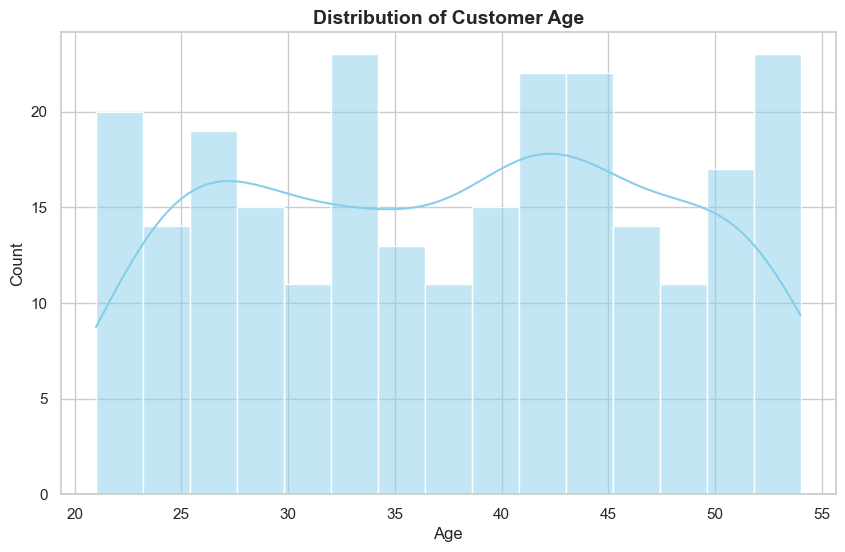

In [6]:
# ---------- Univariate Plot 1: Age Distribution ----------
plt.figure(figsize=(10, 6))
sns.histplot(df["Age"], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Customer Age", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

> **Insight:** Most customers fall between ages 40 and 45, indicating the dataset mainly represents working-age adults. Very few customers are at the extreme young or older ends.

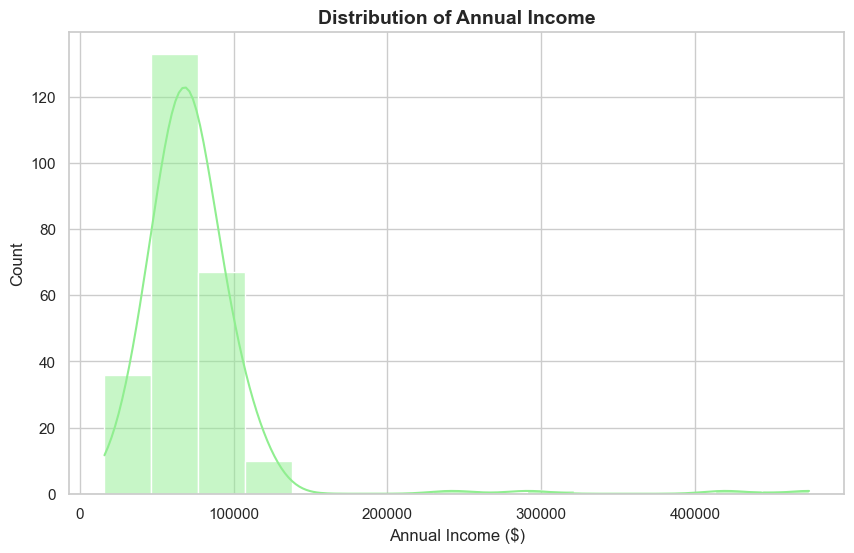

In [7]:
# ---------- Univariate Plot 2: Annual Income ----------
plt.figure(figsize=(10, 6))
sns.histplot(df["AnnualIncome"], bins=15, kde=True, color='lightgreen')
plt.title("Distribution of Annual Income", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income ($)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

> **Insight:** Income distribution is spread widely with some high-income outliers. This suggests customers come from diverse economic backgrounds, though the majority are concentrated in the lower-to-middle income brackets.

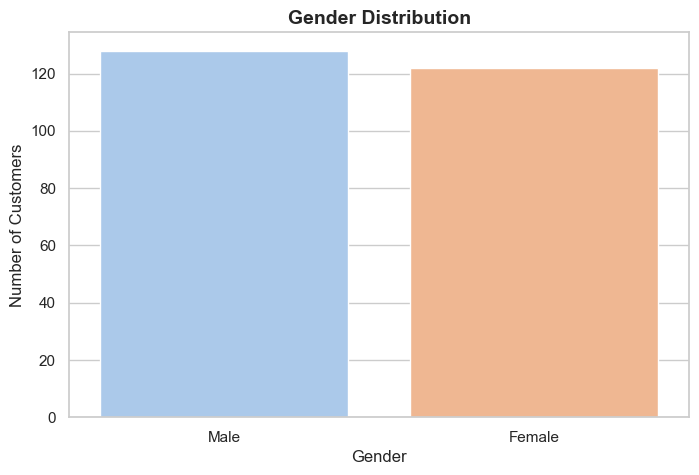

In [8]:
# ---------- Univariate Plot 3: Gender Count ----------
plt.figure(figsize=(8, 5))
sns.countplot(x="Gender", data=df, palette="pastel")
plt.title("Gender Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.show()

> **Insight:** The gender ratio is relatively balanced, with the male customer count being slightly higher. This shows that both demographic segments participate equally in purchasing.

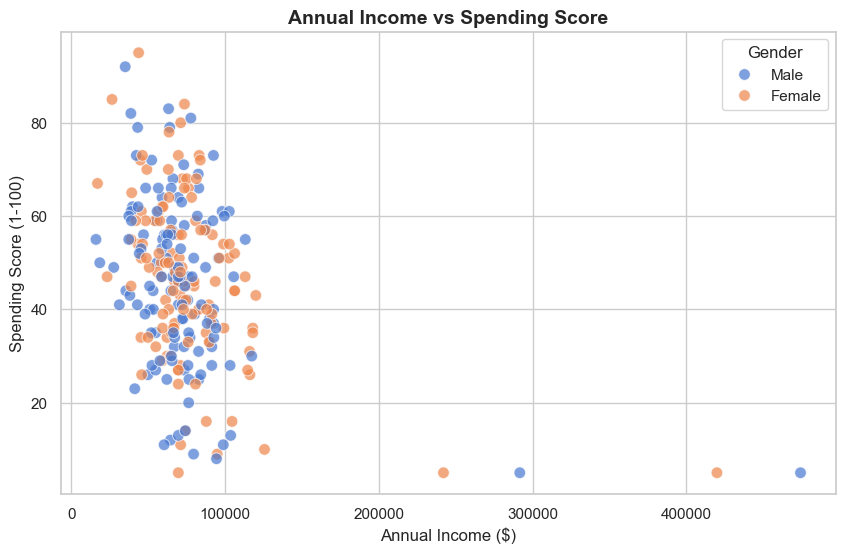

In [9]:
# ---------- Bivariate Plot 1: Income vs Spending ----------
plt.figure(figsize=(10, 6))
sns.scatterplot(x="AnnualIncome", y="SpendingScore", hue="Gender", data=df, alpha=0.7, s=70)
plt.title("Annual Income vs Spending Score", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income ($)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)
plt.legend(title="Gender")
plt.show()

> **Insight:** There is no strong linear relationship between income and spending score. Interestingly, higher-income customers don't strictly spend more, while low-income customers exhibit widely varying spending patterns. This indicates that income alone does not dictate spending behavior.

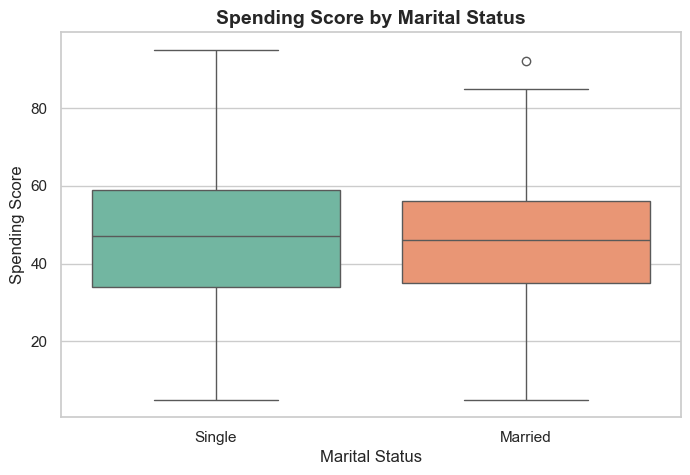

In [10]:
# ---------- Bivariate Plot 2: Spending by Marital Status ----------
plt.figure(figsize=(8, 5))
sns.boxplot(x="MaritalStatus", y="SpendingScore", data=df, palette="Set2")
plt.title("Spending Score by Marital Status", fontsize=14, fontweight='bold')
plt.xlabel("Marital Status", fontsize=12)
plt.ylabel("Spending Score", fontsize=12)
plt.show()

> **Insight:** Single customers generally have a higher upper bound of spending. However, there is a distinct outlier present in the "Married" category that shows excessive spending.

## Phase 4: Big Picture (Multivariate & Storytelling)

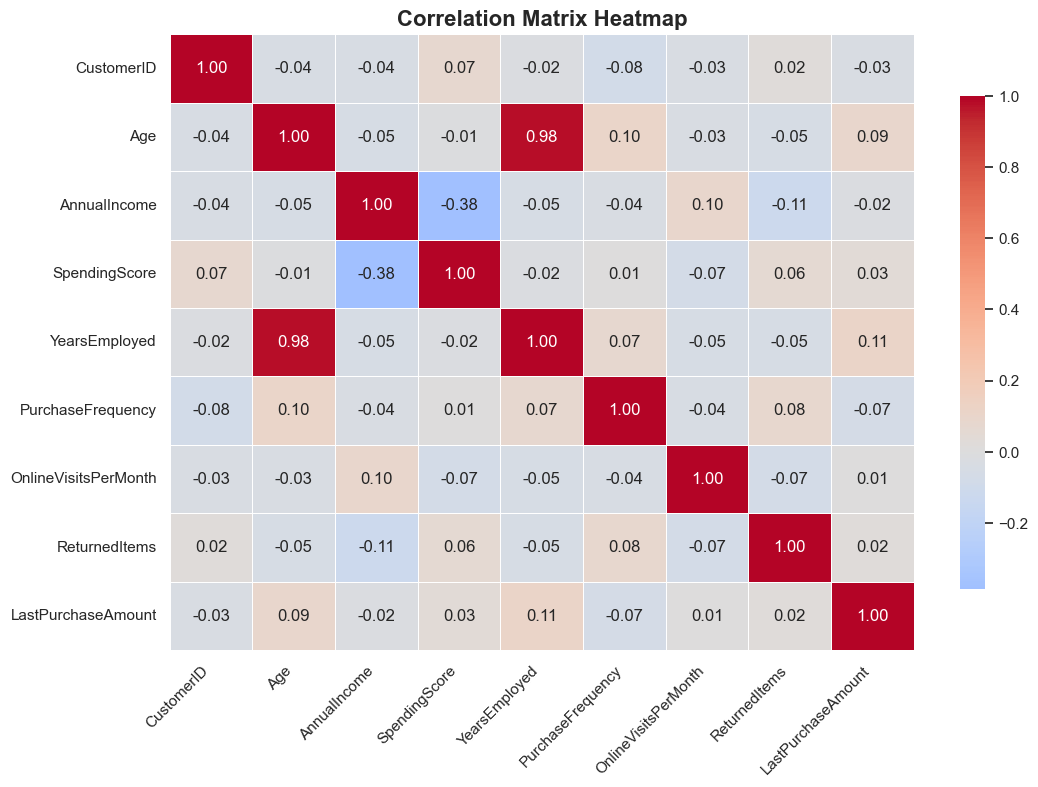

In [11]:
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=["int64", "float64"])

# Calculate the correlation matrix
corr = num_df.corr()

# ---------- Correlation Matrix Heatmap ----------
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

> **Insight:** The heatmap reveals relationships between numerical variables. Strong positive (red) or negative (blue) correlations indicate variables that move together, which is highly useful for feature selection in predictive modeling.

## Executive Summary — Top 3 Insights

1. **Customer Base Profile**: 
   Most customers are middle-aged working professionals with moderate employment experience.
2. **Income vs. Spending Behavior**: 
   Higher income does not automatically translate to higher spending, suggesting that psychological, demographic, or lifestyle factors heavily influence purchasing habits.
3. **Digital Engagement**: 
   Customers show moderate online activity across various preferred devices, indicating a strong potential for targeted digital marketing strategies.